<a href="https://colab.research.google.com/github/atortosalopez/trabajo-final-sentimientos/blob/main/notebooks/05_comparacion_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import files

files.upload()

Saving corpus_pred_dl.csv to corpus_pred_dl.csv
Saving corpus_pred_lexicon.csv to corpus_pred_lexicon.csv
Saving corpus_pred_ml.csv to corpus_pred_ml.csv
Saving corpus_pred_tl.csv to corpus_pred_tl.csv


{'corpus_pred_dl.csv': b'text,label,pred_dl\ndid the film inform and educate me ? yes . did it move me to care about what happened in 1915 armenia ? no . and that is where ararat went astray .,0,0\nan unsophisticated sci-fi drama that takes itself all too seriously .,0,0\nit seems like i have been waiting my whole life for this movie and now i can\'t wait for the sequel .,1,0\nthe stories here suffer from the chosen format .,0,1\nit\'s dark but has wonderfully funny moments ; you care about the characters ; and the action and special effects are first-rate .,1,1\n"as a witness to several greek-american weddings -- but , happily , a victim of none -- i can testify to the comparative accuracy of ms . vardalos\' memories and insights .",1,1\n"not that any of us should be complaining when a film clocks in around 90 minutes these days , but the plotting here leaves a lot to be desired .",0,0\nfirst-time director jo\xc3\xa3o pedro rodrigues\' unwillingness to define his hero\'s background or

In [2]:
lex = pd.read_csv("corpus_pred_lexicon.csv")
ml = pd.read_csv("corpus_pred_ml.csv")
dl = pd.read_csv("corpus_pred_dl.csv")
tl = pd.read_csv("corpus_pred_tl.csv")

df = lex[["text", "label"]].copy()

df["pred_lexicon"] = lex["pred_lexicon"]
df["pred_ml"] = ml["pred_ml"]
df["pred_dl"] = dl["pred_dl"]
df["pred_tl"] = tl["pred_tl"]

print(df.head())

                                                text  label  pred_lexicon  \
0  did the film inform and educate me ? yes . did...      0             1   
1  an unsophisticated sci-fi drama that takes its...      0             0   
2  it seems like i have been waiting my whole lif...      1             1   
3   the stories here suffer from the chosen format .      0             0   
4  it's dark but has wonderfully funny moments ; ...      1             1   

   pred_ml  pred_dl  pred_tl  
0        0        0        0  
1        0        0        0  
2        0        0        0  
3        1        1        0  
4        1        1        1  


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

In [4]:
results = []

for model in ["pred_lexicon", "pred_ml", "pred_dl", "pred_tl"]:
    metrics = evaluate(df["label"], df[model])
    metrics["model"] = model
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df = results_df[["model", "accuracy", "precision", "recall", "f1"]]

results_df

,model,accuracy,precision,recall,f1
0,pred_lexicon,0.61875,0.581756,0.84500,0.689093
1,pred_ml,0.76625,0.764925,0.76875,0.766833
2,pred_dl,0.76625,0.742597,0.81500,0.777116
3,pred_tl,0.87500,0.896825,0.84750,0.871465


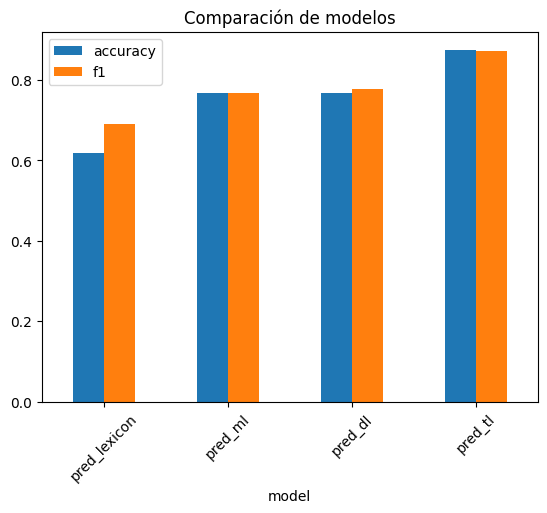

In [5]:
import matplotlib.pyplot as plt

results_df.set_index("model")[["accuracy", "f1"]].plot(kind="bar")
plt.title("Comparación de modelos")
plt.xticks(rotation=45)
plt.show()

In [6]:
errors = df[
    (df["pred_lexicon"] != df["label"]) |
    (df["pred_ml"] != df["label"]) |
    (df["pred_dl"] != df["label"]) |
    (df["pred_tl"] != df["label"])
]

errors[["text", "label", "pred_lexicon", "pred_ml", "pred_dl", "pred_tl"]].head(10)

,text,label,pred_lexicon,pred_ml,pred_dl,pred_tl
0,did the film inform and educate me ? yes . did...,0,1,0,0,0
2,it seems like i have been waiting my whole lif...,1,1,0,0,0
3,the stories here suffer from the chosen format .,0,0,1,1,0
5,as a witness to several greek-american wedding...,1,1,0,1,1
6,not that any of us should be complaining when ...,0,1,0,0,0
10,"the real star of this movie is the score , as ...",1,1,0,1,1
16,this remake gets all there is to get out of a ...,1,0,0,0,0
18,"the bottom line , at least in my opinion , is ...",0,1,0,0,0
19,a collage of clichés and a dim echo of allusio...,0,1,0,0,0
20,when a set of pre-shooting guidelines a direct...,0,1,0,0,0


In [7]:
case = df[
    (df["pred_tl"] == df["label"]) &
    (df["pred_lexicon"] != df["label"])
]

case[["text", "label", "pred_lexicon", "pred_tl"]].head(5)

,text,label,pred_lexicon,pred_tl
0,did the film inform and educate me ? yes . did...,0,1,0
6,not that any of us should be complaining when ...,0,1,0
18,"the bottom line , at least in my opinion , is ...",0,1,0
19,a collage of clichés and a dim echo of allusio...,0,1,0
20,when a set of pre-shooting guidelines a direct...,0,1,0


In [8]:
df.to_csv("corpus_completo.csv", index=False)